# Recursive Convergent Inference (RCI)
### Proof-of-Concept Experiment

**Paper:** Recursive Convergent Inference: Bottom-Up Module Expansion via Output Convergence  
**Author:** Alex Anokhin (olanokhin@gmail.com)  
**GitHub:** https://github.com/olanokhin/rci-inference  
**Colab:** https://colab.research.google.com/drive/1hKGM_matDR-JZb-qk20x2gQ3aYiovhqx?usp=sharing

---

**Setup:**
1. Add `HF_TOKEN` to Colab Secrets — left panel → 🔑 → Name: `HF_TOKEN`
2. Run **Cell 1** (install), then **Runtime → Restart session**
3. Run all remaining cells in order

**Runtime:** ~60 minutes on free T4 GPU  
**Results:** Reproduces all statistics reported in the paper (n=150, Spearman ρ=0.21, p=0.009)

In [1]:
# Cell 0: Install correct version
!pip install -q transformers==4.45.0 datasets accelerate
import importlib, transformers
importlib.reload(transformers)
print(f"transformers=={transformers.__version__}")

transformers==4.45.0


In [2]:
# Cell 2: Authenticate and load model
import torch, numpy as np, json, matplotlib.pyplot as plt
from itertools import combinations
from collections import defaultdict
from scipy.stats import mannwhitneyu, spearmanr
from matplotlib.lines import Line2D
from transformers import AutoTokenizer, OlmoeForCausalLM
from datasets import load_dataset
from huggingface_hub import login
from google.colab import userdata

login(token=userdata.get("HF_TOKEN"))

DEVICE   = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_ID = "allenai/OLMoE-1B-7B-0924"
print(f"Device: {DEVICE}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model     = OlmoeForCausalLM.from_pretrained(
    MODEL_ID, torch_dtype=torch.float16, device_map="auto"
)
model.eval()
NUM_EXPERTS = 64
BASE_TOP_K  = 8
print(f"Model loaded. Experts={NUM_EXPERTS} | top-k={BASE_TOP_K}")

Device: cuda


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Model loaded. Experts=64 | top-k=8


In [3]:
# Cell 3: Helper functions

def get_router_decisions(model, input_ids):
    activated = defaultdict(list)
    hooks = []
    for li, layer in enumerate(model.model.layers):
        if hasattr(layer, "mlp") and hasattr(layer.mlp, "gate"):
            def make_hook(i):
                def hook(m, inp, out):
                    logits = out[0] if isinstance(out, tuple) else out
                    activated[i].extend(
                        torch.topk(logits, k=BASE_TOP_K, dim=-1).indices.flatten().tolist()
                    )
                return hook
            hooks.append(layer.mlp.gate.register_forward_hook(make_hook(li)))
    with torch.no_grad():
        model(input_ids.to(DEVICE))
    for h in hooks:
        h.remove()
    return activated

def kl_div(p, q, eps=1e-8):
    p = torch.softmax(p, dim=-1).float() + eps
    q = torch.softmax(q, dim=-1).float() + eps
    return float((p * (p / q).log()).sum())

def conf_margin(logits):
    t = torch.topk(torch.softmax(logits, dim=-1), k=2).values
    return float(t[0] - t[1])

def get_seeds(model, ids, n=8):
    d = get_router_decisions(model, ids)
    c = defaultdict(int)
    for ex in d.values():
        for e in ex:
            c[e] += 1
    return set(sorted(c, key=c.get, reverse=True)[:n])

def bfs_expand(M, affinity, k=4):
    s = np.zeros(NUM_EXPERTS)
    for e in M:
        s += affinity[e]
    s[list(M)] = -1
    return M | set(np.argsort(s)[-k:].tolist())

class GatingMask:
    def __init__(self, model, allowed, top_k):
        self.model = model
        self.allowed = allowed
        self.top_k = top_k
        self.hooks = []

    def __enter__(self):
        at = torch.tensor(list(self.allowed), device=DEVICE)
        for layer in self.model.model.layers:
            if hasattr(layer, "mlp") and hasattr(layer.mlp, "gate"):
                def make_hook(a):
                    def hook(m, i, o):
                        # Fix: handle tuple output from gate
                        logits = o[0] if isinstance(o, tuple) else o
                        mask = torch.full_like(logits, float("-inf"))
                        mask[:, a] = logits[:, a]
                        if isinstance(o, tuple):
                            return (mask,) + o[1:]
                        return mask
                    return hook
                self.hooks.append(
                    layer.mlp.gate.register_forward_hook(make_hook(at))
                )
        return self

    def __exit__(self, *args):
        for h in self.hooks:
            h.remove()

def rci_inference(model, tokenizer, prompt,
                  max_steps=15, W=3, eps=0.093, theta=0.01, verbose=False):
    ids = tokenizer(prompt, return_tensors="pt",
                    truncation=True, max_length=256)["input_ids"]
    M = get_seeds(model, ids)
    prev = None
    kl_hist = []
    win = []
    for step in range(max_steps):
        k = min(BASE_TOP_K * (2 ** step), NUM_EXPERTS)
        with GatingMask(model, M, k):
            with torch.no_grad():
                logits = model(ids.to(DEVICE)).logits[0, -1, :]
        if prev is not None:
            kl = kl_div(logits, prev)
            m  = conf_margin(logits)
            win.append(kl)
            kl_hist.append(kl)
            roll = np.mean(win[-W:])
            if verbose:
                print(f"  step {step:2d} | M={len(M):3d} | KL={kl:.4f} | "
                      f"margin={m:.4f} | roll={roll:.4f}")
            if roll < eps:
                break
            if m >= 0.3 and roll < eps * 3:
                break
        M = bfs_expand(M, affinity, k=4)
        prev = logits.clone()
    with torch.no_grad():
        gen = model.generate(ids.to(DEVICE), max_new_tokens=20, do_sample=False)
    ans = tokenizer.decode(gen[0][ids.shape[1]:], skip_special_tokens=True)
    return ans, step + 1, len(M) / NUM_EXPERTS, kl_hist

print("Helpers defined.")

Helpers defined.


In [4]:
# Cell 4: Phase 1 — Co-activation affinity graph (~10 min)
print("Building affinity graph...")
affinity = np.zeros((NUM_EXPERTS, NUM_EXPERTS), dtype=np.float32)
c4 = iter(load_dataset("allenai/c4", "en", split="train", streaming=True))

for i in range(500):
    ids = tokenizer(
        next(c4)["text"][:256], return_tensors="pt",
        truncation=True, max_length=64
    )["input_ids"]
    for ex in get_router_decisions(model, ids).values():
        for a, b in combinations(set(ex), 2):
            affinity[a][b] += 1
            affinity[b][a] += 1
    if (i + 1) % 100 == 0:
        print(f"  {i+1}/500")

mx = affinity.max()
if mx > 0:
    affinity /= mx
print(f"Done. Non-zero edges: {(affinity > 0).sum()}")

Building affinity graph...


Resolving data files:   0%|          | 0/1024 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1024 [00:00<?, ?it/s]

  100/500
  200/500
  300/500
  400/500
  500/500
Done. Non-zero edges: 4032


In [5]:
# Cell 5: Load datasets (GSM8K / MATH / MMLU hard)
def load_tasks(n=50):
    tasks = []
    for ex in load_dataset("gsm8k", "main", split="test").select(range(n)):
        tasks.append({"difficulty": "easy",
                      "prompt": f"Question: {ex['question']}\nAnswer:"})
    print(f"GSM8K: {n}")
    try:
        ds = load_dataset("EleutherAI/hendrycks_math", "algebra", split="test")
        for ex in ds.select(range(n)):
            tasks.append({"difficulty": "medium",
                          "prompt": f"Problem: {ex['problem']}\nSolution:"})
        print(f"MATH algebra: {n}")
    except Exception as e:
        print(f"MATH skip: {e}")
    try:
        hard = []
        for subj in ["college_physics", "college_chemistry",
                     "abstract_algebra", "formal_logic"]:
            ds = load_dataset("cais/mmlu", subj, split="test")
            for ex in ds.select(range(n // 4 + 1)):
                hard.append({
                    "difficulty": "hard",
                    "prompt": (
                        f"Question: {ex['question']}\n"
                        f"A) {ex['choices'][0]}\n"
                        f"B) {ex['choices'][1]}\n"
                        f"C) {ex['choices'][2]}\n"
                        f"D) {ex['choices'][3]}\nAnswer:"
                    )
                })
        tasks.extend(hard[:n])
        print(f"MMLU hard: {len(hard[:n])}")
    except Exception as e:
        print(f"MMLU skip: {e}")
    return tasks

tasks = load_tasks(50)
print(f"Total: {len(tasks)}")

GSM8K: 50
MATH algebra: 50
MMLU hard: 50
Total: 150


In [6]:
# Cell 6: Phase 2 — RCI inference (~60 min on T4)
print("=== Phase 2: RCI inference ===\n")
results = []
for i, t in enumerate(tasks):
    _, steps, pct, kl = rci_inference(model, tokenizer, t["prompt"])
    results.append({
        "difficulty": t["difficulty"],
        "steps": steps,
        "pct": pct,
        "kl": kl
    })
    print(f"[{i+1:3d}/{len(tasks)}] {t['difficulty']:6s} | "
          f"steps={steps:2d} | experts={pct*100:.1f}% | AUC={sum(kl):.2f}")

=== Phase 2: RCI inference ===

[  1/150] easy   | steps=10 | experts=68.8% | AUC=8.49
[  2/150] easy   | steps=13 | experts=87.5% | AUC=7.85
[  3/150] easy   | steps=15 | experts=100.0% | AUC=6.69
[  4/150] easy   | steps=15 | experts=100.0% | AUC=13.17
[  5/150] easy   | steps=15 | experts=100.0% | AUC=10.51
[  6/150] easy   | steps=15 | experts=100.0% | AUC=10.72
[  7/150] easy   | steps=15 | experts=100.0% | AUC=9.67
[  8/150] easy   | steps=11 | experts=75.0% | AUC=9.78
[  9/150] easy   | steps=15 | experts=100.0% | AUC=8.90
[ 10/150] easy   | steps=11 | experts=75.0% | AUC=8.36
[ 11/150] easy   | steps=15 | experts=100.0% | AUC=10.02
[ 12/150] easy   | steps=13 | experts=87.5% | AUC=17.62
[ 13/150] easy   | steps=15 | experts=100.0% | AUC=14.68
[ 14/150] easy   | steps=15 | experts=100.0% | AUC=11.38
[ 15/150] easy   | steps=15 | experts=100.0% | AUC=9.06
[ 16/150] easy   | steps=13 | experts=87.5% | AUC=10.26
[ 17/150] easy   | steps=15 | experts=100.0% | AUC=9.72
[ 18/150] easy

In [7]:
# Cell 7: Statistical analysis
e = [sum(r["kl"]) for r in results if r["difficulty"] == "easy"]
m = [sum(r["kl"]) for r in results if r["difficulty"] == "medium"]
h = [sum(r["kl"]) for r in results if r["difficulty"] == "hard"]

s1, p1 = mannwhitneyu(h, e, alternative="greater")
s2, p2 = mannwhitneyu(h, m, alternative="greater")
s3, p3 = mannwhitneyu(e, m, alternative="greater")
rho, p_sp = spearmanr([0]*len(e) + [1]*len(m) + [2]*len(h), e + m + h)

for d, a in [("easy", e), ("medium", m), ("hard", h)]:
    print(f"  {d:6s}: {np.mean(a):.3f} +/- {np.std(a):.3f}  (n={len(a)})")
print(f"Hard > Easy:   U={s1:.0f}, p={p1:.4f}")
print(f"Hard > Medium: U={s2:.0f}, p={p2:.4f}")
print(f"Easy > Medium: U={s3:.0f}, p={p3:.4f}")
print(f"Spearman rho={rho:.3f}, p={p_sp:.4f}, n={len(e+m+h)}")

  easy  : 10.728 +/- 2.808  (n=50)
  medium: 8.956 +/- 1.688  (n=50)
  hard  : 11.987 +/- 2.537  (n=50)
Hard > Easy:   U=1677, p=0.0016
Hard > Medium: U=2106, p=0.0000
Easy > Medium: U=1788, p=0.0001
Spearman rho=0.221, p=0.0066, n=150


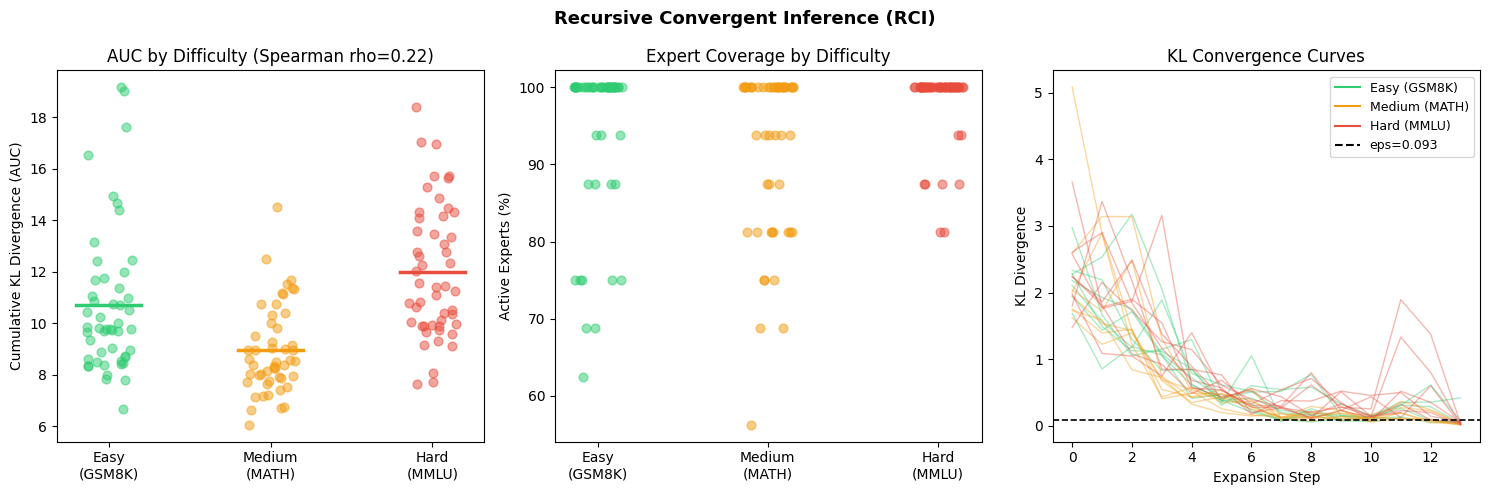

Saved: rci_figure1.png


In [8]:
# Cell 8: Visualisation
colors = {"easy": "#2ecc71", "medium": "#f39c12", "hard": "#e74c3c"}
order  = {"easy": 0, "medium": 1, "hard": 2}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Recursive Convergent Inference (RCI)", fontsize=13, fontweight="bold")

e_a = [sum(r["kl"]) for r in results if r["difficulty"] == "easy"]
m_a = [sum(r["kl"]) for r in results if r["difficulty"] == "medium"]
h_a = [sum(r["kl"]) for r in results if r["difficulty"] == "hard"]

for r in results:
    x = order[r["difficulty"]] + np.random.uniform(-0.15, 0.15)
    axes[0].scatter(x, sum(r["kl"]),  color=colors[r["difficulty"]], alpha=0.5, s=40)
    axes[1].scatter(x, r["pct"]*100, color=colors[r["difficulty"]], alpha=0.5, s=40)

for d, a in [("easy", e_a), ("medium", m_a), ("hard", h_a)]:
    axes[0].plot([order[d]-.2, order[d]+.2], [np.mean(a)]*2,
                 color=colors[d], linewidth=2.5)

for ax in axes[:2]:
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(["Easy\n(GSM8K)", "Medium\n(MATH)", "Hard\n(MMLU)"])
axes[0].set_ylabel("Cumulative KL Divergence (AUC)")
axes[0].set_title(f"AUC by Difficulty (Spearman rho={rho:.2f})")
axes[1].set_ylabel("Active Experts (%)")
axes[1].set_title("Expert Coverage by Difficulty")

for d, c in colors.items():
    for r in [r for r in results if r["difficulty"] == d][:8]:
        axes[2].plot(r["kl"], color=c, alpha=0.4, linewidth=1)
axes[2].axhline(y=0.093, color="black", linestyle="--", linewidth=1.2)
axes[2].set_xlabel("Expansion Step")
axes[2].set_ylabel("KL Divergence")
axes[2].set_title("KL Convergence Curves")
axes[2].legend(handles=[
    Line2D([0],[0], color=colors["easy"],   label="Easy (GSM8K)"),
    Line2D([0],[0], color=colors["medium"], label="Medium (MATH)"),
    Line2D([0],[0], color=colors["hard"],   label="Hard (MMLU)"),
    Line2D([0],[0], color="black", linestyle="--", label="eps=0.093"),
], fontsize=9)

plt.tight_layout()
plt.savefig("rci_figure1.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: rci_figure1.png")

In [9]:
# Cell 9: Save results
e = [sum(r["kl"]) for r in results if r["difficulty"] == "easy"]
m = [sum(r["kl"]) for r in results if r["difficulty"] == "medium"]
h = [sum(r["kl"]) for r in results if r["difficulty"] == "hard"]

output = {
    "model": "allenai/OLMoE-1B-7B-0924",
    "n": len(results),
    "eps": 0.093,
    "stats": {
        "easy":   {"mean": round(float(np.mean(e)), 3), "std": round(float(np.std(e)), 3)},
        "medium": {"mean": round(float(np.mean(m)), 3), "std": round(float(np.std(m)), 3)},
        "hard":   {"mean": round(float(np.mean(h)), 3), "std": round(float(np.std(h)), 3)},
    },
    "spearman": {"rho": round(float(rho), 3), "p": round(float(p_sp), 4)},
}
with open("rci_results.json", "w") as f:
    json.dump(output, f, indent=2)
print(json.dumps(output, indent=2))
print("Saved: rci_results.json")

{
  "model": "allenai/OLMoE-1B-7B-0924",
  "n": 150,
  "eps": 0.093,
  "stats": {
    "easy": {
      "mean": 10.728,
      "std": 2.808
    },
    "medium": {
      "mean": 8.956,
      "std": 1.688
    },
    "hard": {
      "mean": 11.987,
      "std": 2.537
    }
  },
  "spearman": {
    "rho": 0.221,
    "p": 0.0066
  }
}
Saved: rci_results.json
